Аппроксимация эпсилон по данным ППР чистого InSb и 1 слоя графеновой пленки для проверки корректности кода
42.2 grad - внутренний угол

Итоги: 1) InSb [ 6.99408267e-01 -7.54008207e-06 -1.46662532e+01  5.06988187e+00] - reasonable, err= [2.01677993e-02 3.85870581e-02 4.64851890e+03 1.52863224e+03] - huge error
2) 1 layer - out of bound!!

In [54]:
from numpy import array, sqrt, sin, linspace, inf, pi
import numpy as np
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import glob
import sys
import sympy as sy
import ipywidgets as widgets
import tmm
sys.path.append(r'C:\Users\belco\Documents\Graphene\Graphene-films-plasmon-refractometry\lib')
from reflect import reflect3, reflect4

{'C:\\Users\\belco\\Documents\\Graphene\\Data\\Raw data\\Gerasimov from paper\\SPR_InSb+Gr-1 layer_197 um_from_Gerasimov_paper.dat':       Gap      Norm     Error
1     6.2  0.486253  0.024313
2    22.4  0.426900  0.021345
3    38.6  0.335180  0.016759
4    54.8  0.224788  0.011239
5    71.0  0.148145  0.007407
6    87.2  0.111582  0.005579
7   103.4  0.106787  0.005339
8   111.5  0.097858  0.004893
9   119.6  0.113159  0.005658
10  127.7  0.134562  0.006728
11  135.8  0.140871  0.007044
12  152.0  0.241509  0.012075
13  168.2  0.302125  0.015106
14  184.4  0.430188  0.021509
15  200.6  0.530482  0.026524
16  216.8  0.618312  0.030916
17  233.0  0.745111  0.037256
18  314.0  0.894313  0.044716
19  395.0  0.916962  0.045848
20  476.0  0.999980  0.049999, 'C:\\Users\\belco\\Documents\\Graphene\\Data\\Raw data\\Gerasimov from paper\\SPR_pure_InSb_197 um_Gerasimov.dat':       Gap      Norm     Error
1     8.6  0.521970  0.052197
2    25.2  0.504518  0.050452
3    41.8  0.477994  0.047799
4

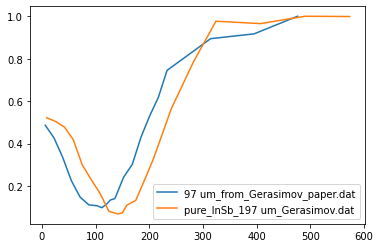

In [100]:
file_paths = glob.glob(r"C:\Users\belco\Documents\Graphene\Data\Raw data\Gerasimov from paper/*.dat")
data_dict = {}
def create_data_dict(file_paths):
    for name in file_paths:
        data = pd.read_csv(name, sep='\t', decimal='.')
        data_dict[name] = data.apply(pd.to_numeric, errors='coerce').dropna()
        plt.plot(data_dict[name]['Gap'], data_dict[name]['Norm'], label=name[-30:])
    return data_dict 
data_dict = create_data_dict(file_paths)
print(data_dict)

plt.legend()
plt.show()

[ 6.99408267e-01 -7.54008207e-06 -1.46662532e+01  5.06988187e+00] [2.01677993e-02 3.85870581e-02 4.64851890e+03 1.52863224e+03]


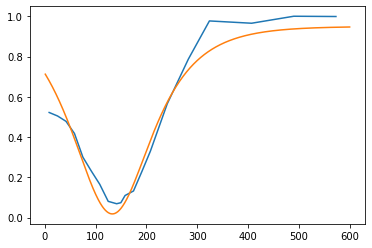

In [93]:
def theta_from_ext(angle_ext, n_1):
    angle_int = pi/4 - tmm.arcsin(sin(pi/4 - angle_ext) / n_1)
    return angle_int



#fitting function   
def fit_func_InSb(gap_arr, theta_ext, shift,  eps_re, eps_im):
    n_pr = 1.531 - 1j * 0.002
    eps_pr = n_pr**2
    th_0 = theta_from_ext(theta_ext, n_pr)
    lam_vac = 197*1e-6
    return reflect3(gap_arr - np.ones(gap_arr.size, dtype=np.float64)*shift, th_0,  eps_pr.real, eps_pr.imag, 1, 0, eps_re, eps_im)



# fitting
def fitting_InSb():
    filename = 'C:\\Users\\belco\\Documents\\Graphene\\Data\\Raw data\\Gerasimov from paper\\SPR_pure_InSb_197 um_Gerasimov.dat'
    data = data_dict[filename]
    x_data = np.array(data['Gap'])*1e-6
    y_data = np.array(data['Norm'])
    # sigma (incertainity) = default = 1, (не важно, она все равно одинаковая в процентах)
    params, pcov = curve_fit(fit_func_InSb, x_data, y_data, bounds=[(0.2*pi, -1e-5, -inf, 0), (0.3*pi, 1e-5, 0, inf)])
    perr = np.sqrt(np.diag(pcov))
    print(params, perr)
    plt.plot(data_dict[filename]['Gap'], data_dict[filename]['Norm'])
    plt.plot(linspace(1, 600, 600), fit_func_InSb(linspace(1e-6, 600e-6, 600), 
                                                  *params))

fitting_InSb()




[-25.         630.52388282] [[4780.80499741  163.40009256]
 [ 163.40009256 3939.18035574]]


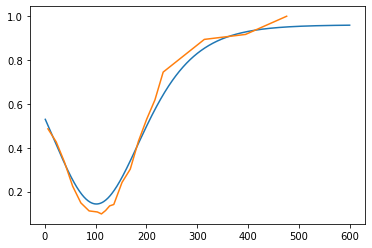

In [ ]:
# fitting 1 layer; InSb - table
def fit_func_1_layer(gap_arr, eps3_re, eps3_im):
    return np.array(reflect4(gap_arr + 7.54008207e-06, 35e-9, 
                    teta = np.radians(42.2), eps3_re=eps3_re, eps3_im=eps3_im, eps4_re=-17, eps4_im=7))


plt.show()
def fitting_1_layer():
    filename = 'C:\\Users\\belco\\Documents\\Graphene\\Data\\Raw data\\Gerasimov from paper\\SPR_InSb+Gr-1 layer_197 um_from_Gerasimov_paper.dat'
    data = data_dict[filename]
    x_data = np.array(data['Gap'])*1e-6
    y_data = np.array(data['Norm'])
    params, pcov = curve_fit(fit_func_1_layer, x_data, y_data, bounds=[(-inf, 10), (-25, inf)])
    # sigma (incertainity) = default = 1, (не важно, она все равно одинаковая в процентах)
    plt.plot(linspace(1, 600, 600), fit_func_1_layer(linspace(1e-6, 600e-6, 600), *params))
    plt.plot(data['Gap'], data['Norm'])
    print(params, pcov)

fitting_1_layer()

In [45]:
help(curve_fit)

Help on function curve_fit in module scipy.optimize._minpack_py:

curve_fit(f, xdata, ydata, p0=None, sigma=None, absolute_sigma=False, check_finite=True, bounds=(-inf, inf), method=None, jac=None, *, full_output=False, **kwargs)
    Use non-linear least squares to fit a function, f, to data.
    
    Assumes ``ydata = f(xdata, *params) + eps``.
    
    Parameters
    ----------
    f : callable
        The model function, f(x, ...). It must take the independent
        variable as the first argument and the parameters to fit as
        separate remaining arguments.
    xdata : array_like or object
        The independent variable where the data is measured.
        Should usually be an M-length sequence or an (k,M)-shaped array for
        functions with k predictors, but can actually be any object.
    ydata : array_like
        The dependent data, a length M array - nominally ``f(xdata, ...)``.
    p0 : array_like, optional
        Initial guess for the parameters (length N). If No